# Childhood Trauma and Adult Mental Health in Women

In [53]:
##### 1. SETUP AND DATA LOADING

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind, spearmanr
import statsmodels.formula.api as smf

df = pd.read_csv("https://raw.githubusercontent.com/sk5655-debug/Stuti-Karna-Final/main/midus1_subset_v2.csv")

In [55]:
##### 2. CLEANING AND RENAMING VARIABLES FOR GENDER-BASED COMPARISONS
# creating new columns which only have the relevant values for depression (yes/no), depression score and substance use
df["depression"] = df["A1PDEPDX"]  # already 0/1 so just creates the column
df["dep_score"]  = df["A1PDEPAF"].replace({-1.0:np.nan}) #np.nan helps remove the missing data
df["substance_use"]  = df["A1SA9U"].replace({1.0:1, 2.0:0, -1.0:np.nan, 8.0:np.nan}) # data includes yes = 1, no = 2, missing data = -1, invalid responses = 8

# Split the dataset to compare men and women on depression and substance use --> before filtering to women only
men = df[df["A1PRSEX"] == 1.0]
women = df[df["A1PRSEX"] == 2.0]

n_men = len(men)
n_women = len(women)
print("Sample Sizes")
print(f"Men: {n_men}")
print(f"Women: {n_women}")

#rate of depression in each group
men_dep_rate = men["depression"].mean() * 100
women_dep_rate = women["depression"].mean() * 100

#rate of substance use in each group
men_SA_rate = men["substance_use"].mean() * 100
women_SA_rate = women["substance_use"].mean() * 100

print("Gender Comparison")
print(f"Depression  — Men: {round(men_dep_rate,1)}%  Women: {round(women_dep_rate,1)}%")
print(f"Substance use — Men: {round(men_SA_rate,1)}%  Women: {round(women_SA_rate,1)}%")

Sample Sizes
Men: 3440
Women: 3666
Gender Comparison
Depression  — Men: 10.3%  Women: 16.0%
Substance use — Men: 3.7%  Women: 1.5%


In [56]:
##### 3. independent sample t-test MEN VS WOMEN

men_scores = men["dep_score"].dropna()
women_scores = women["dep_score"].dropna()

t, p = ttest_ind(men_scores, women_scores,
                 equal_var=False) # Welch's t-test unequal variance assumed

# Create significance labels
def sig_label(p):
    if p < 0.001: return "p<0.001***"
    elif p < 0.01: return "p<0.01**"
    elif p < 0.05: return "p<0.05*"
    else: return "ns"


#Calculate effect size Cohen's d
mean_diff = men_scores.mean() - women_scores.mean()

# calculate pooled SD
pooled_sd = np.sqrt(
    ((men_scores.std()**2) + (women_scores.std()**2)) / 2
)
cohens_d = mean_diff / pooled_sd

print(f"T-test depression score (men vs women): t = {round(t,3)} {sig_label(p)}, Cohen's d = {round(cohens_d,3)}")

T-test depression score (men vs women): t = -8.452 p<0.001***, Cohen's d = -0.2


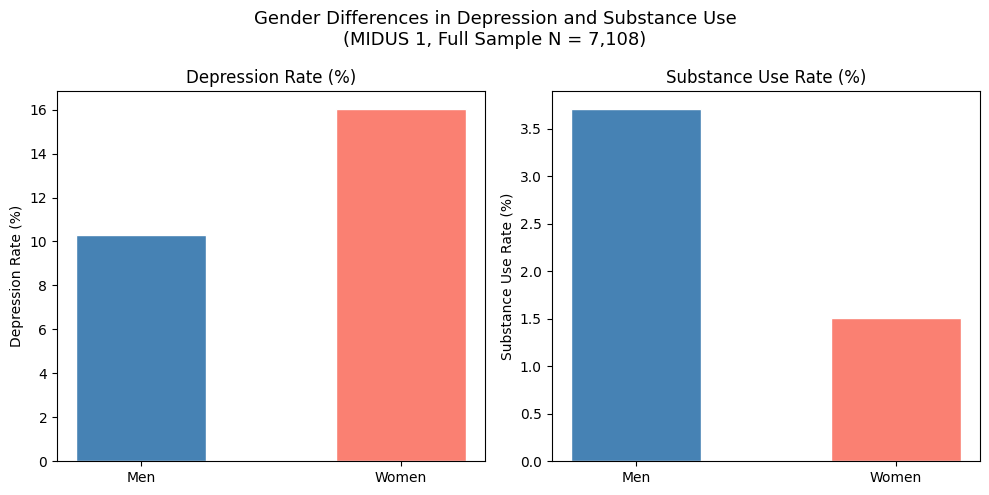

In [57]:
##### 4. bar chart comparing men and women
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Gender Differences in Depression and Substance Use\n(MIDUS 1, Full Sample N = 7,108)", fontsize=13)

for ax, rates, title in zip(
    axes,
    [[men_dep_rate, women_dep_rate], [men_SA_rate, women_SA_rate]],
    ["Depression Rate (%)", "Substance Use Rate (%)"]
):
    ax.bar(["Men", "Women"], rates, color=["steelblue", "salmon"], edgecolor="white", width=0.5)
    ax.set_ylabel(title)
    ax.set_title(title)

plt.tight_layout()
plt.show()

In [58]:
##### 5. FILTER TO WOMEN ONLY
df = df[df["A1PRSEX"] == 2.0].copy()
print("Women only sample:", len(df))

Women only sample: 3666


In [59]:
##### 6. RENAMING + CLEANING VARIABLES

df = df.rename(columns={ #permanently renames the original columns
    "A1PAGE_M2": "age",
    "A1PB1":     "education",
    "A1SHHTOT":  "income",
    "A1SEMAPA":  "abuse_score",   # combined maternal + paternal abuse
    "A1SCTRL":   "sense_control", # sense of control
    "A1SMASTE":  "mastery",       # personal mastery (higher = more mastery)
    "A1SPWBA":   "autonomy",      # psychological autonomy
    "A1PRSEX":   "gender"         # Rename gender column for consistency
})

# Apply cleaning/replacement to the newly renamed columns
df["income"] = df["income"].replace({-1:np.nan, 999999:np.nan, 0:np.nan}) # -1 =missing/dont know/ didnt ask, 999999 = placeholder value for missing income data
df["education"] = df["education"].replace({97:np.nan}) #97 = refused or not reported
df["abuse_score"] = df["abuse_score"].replace({-1:np.nan})
df["sense_control"] = df["sense_control"].replace({-1.0:np.nan, 9.0:np.nan})
df["mastery"]       = df["mastery"].replace({-1.0:np.nan, 99.0:np.nan})
df["autonomy"]      = df["autonomy"].replace({-1.0:np.nan, 99.0:np.nan}) #99 = not calculated
df["log_income"] = np.log(df["income"] + 1) #income is highly skewed so log transformation can reduce the skewness

In [60]:
##### 7. CREATE CHILDHOOD TRAUMA GROUP VARIABLE
# abuse_score runs 1–4 (lower = more abuse, higher = no abuse)
# scores below 3 = abuse present, 3+ = no abuse
df["trauma_group"] = np.where(df["abuse_score"] < 3, "Trauma", np.where(df["abuse_score"] >= 3, "No Trauma", None))

print("\nTrauma distribution:")
print(df["trauma_group"].value_counts()) #count participants in each group

# creating list of abuse questionnaire items
high_abuse_items = ["A1SE17A","A1SE17B","A1SE17C","A1SE17D","A1SE17E",
                    "A1SE17F","A1SE17G","A1SE17H","A1SE17I","A1SE17J",
                    "A1SE17K","A1SE17L","A1SE17M","A1SE17N","A1SE17O"]

# count how many women had at least one item scored 1 or 2 (reported abuse)
any_high_abuse = (df[high_abuse_items].isin([1.0, 2.0])).any(axis=1).sum()
print(f"Women reporting high abuse on at least one item: {any_high_abuse} ({round(any_high_abuse/len(df)*100,1)}%)")


Trauma distribution:
trauma_group
Trauma       1684
No Trauma    1625
Name: count, dtype: int64
Women reporting high abuse on at least one item: 2108 (57.5%)


In [61]:
##### 8. EDUCATION LABELS
#regrouping education levels and handling missing/unmapped values
edu_map = {
    1.0:"No HS diploma", 2.0:"No HS diploma", 3.0:"No HS diploma", 4.0:"No HS diploma",
    5.0:"HS diploma/GED", 6.0:"HS diploma/GED",
    7.0:"Some college",  8.0:"Some college",
    9.0:"College+",     10.0:"College+",     11.0:"College+",     12.0:"College+",
}
df["edu_label"] = df["education"].map(edu_map).fillna("Missing")

In [62]:
##### 9. DESCRIPTIVE STATISTICS
print("\n Education Distribution")
edu = df["edu_label"].value_counts(dropna=False).reset_index()
edu.columns = ["Education", "Count"]
edu["Percent"] = (edu["Count"] / len(df) * 100).round(1)
print(edu)

print("\n Age")
print(f"Mean = {round(df['age'].mean(), 1)} years")
print(f"SD = {round(df['age'].std(), 1)} years")

print("\nIncome summary:")
print(df["income"].describe())
print("Median income:", df["income"].median()) #Income is skewed so median better reflects the typical participant.

df = df.loc[:, ~df.columns.duplicated()]

print("\n Overall Rates")
print("Depression (%):", round(df["depression"].mean() * 100, 1))
print("Substance use (%):", round(df["substance_use"].mean() * 100, 1))

# Sense of control variables
extra_variables = ["sense_control", "mastery", "autonomy"]
extra_variables_table = pd.DataFrame({
    "Mean": df[extra_variables].mean().round(2),
    "SD": df[extra_variables].std().round(2),
    "N": df[extra_variables].count()
})

print("\nSense of Control Variables")
display(extra_variables_table)


 Education Distribution
        Education  Count  Percent
0  HS diploma/GED   1822     49.7
1        College+    942     25.7
2    Some college    476     13.0
3   No HS diploma    419     11.4
4         Missing      7      0.2

 Age
Mean = 46.6 years
SD = 13.1 years

Income summary:
count      3087.000000
mean      67886.783285
std       61445.741312
min         500.000000
25%       27500.000000
50%       48000.000000
75%       85750.000000
max      300000.000000
Name: income, dtype: float64
Median income: 48000.0

 Overall Rates
Depression (%): 16.0
Substance use (%): 1.5

Sense of Control Variables


,Mean,SD,N
sense_control,5.42,1.06,3294
mastery,5.78,1.04,3295
autonomy,16.26,3.44,3294


In [63]:
##### 10. GROUP COMPARISON (TRAUMA vs NO TRAUMA)
df = df.loc[:, ~df.columns.duplicated()] #removes duplicate columns I kept getting everything in the ouput twice

trauma    = df[df["trauma_group"] == "Trauma"]
no_trauma = df[df["trauma_group"] == "No Trauma"]

print("\n Group Sizes")
print("Trauma:", len(trauma), "  No Trauma:", len(no_trauma))

variables = [ #Defining Variables to Compare
  ("depression",   "Depression (%)",   "binary"),
  ("substance_use", "Substance Use (%)", "binary"),
  ("dep_score", "Depression Score", "continuous"),
  ("sense_control", "Sense of Control", "continuous"),
  ("mastery", "Personal Mastery", "continuous"),
  ("autonomy", "Autonomy", "continuous")
]

def get_sig_label(p):
  return "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"

def mean_fmt(x, binary): #formatting means depending on variable type, otherwise the output was weird
  return round(x.mean() * 100, 1) if binary else round(x.mean(), 2)

results = [] # results list
# loop through each outcome variable and run a independent samples t-test (Welch's t test) comparing trauma vs no trauma groups
# Cohen's d as effect size
for var, label, is_binary in variables:
  t = trauma[var].dropna()
  nt = no_trauma[var].dropna()
  t_stat, p = ttest_ind(t, nt, equal_var=False)

  sd_pooled = np.sqrt((t.var() + nt.var()) / 2)
  d = (t.mean() - nt.mean()) / sd_pooled

  results.append({ # I wanted a table
    "Variable": label,
    "Trauma": mean_fmt(t, is_binary),
    "No Trauma": mean_fmt(nt, is_binary),
    "t": round(t_stat, 3),
    "p": "p < 0.001" if p < 0.001 else f"p = {round(p, 4)}",
    "sig": get_sig_label(p),
    "Cohen's d": round(d, 3)
  })

results_df = pd.DataFrame(results)

print("\nGroup Comparison Table")
display(results_df)


 Group Sizes
Trauma: 1684   No Trauma: 1625

Group Comparison Table


,Variable,Trauma,No Trauma,t,p,sig,Cohen's d
0,Depression (%),18.9,10.6,6.779,p < 0.001,***,0.235
1,Substance Use (%),2.1,0.9,2.915,p = 0.0036,**,0.101
2,Depression Score,99.8,55.5,6.545,p < 0.001,***,0.227
3,Sense of Control,526.5,558.4,-8.752,p < 0.001,***,-0.305
4,Personal Mastery,564.3,591.9,-7.681,p < 0.001,***,-0.268
5,Autonomy,1592.6,1661.3,-5.751,p < 0.001,***,-0.201


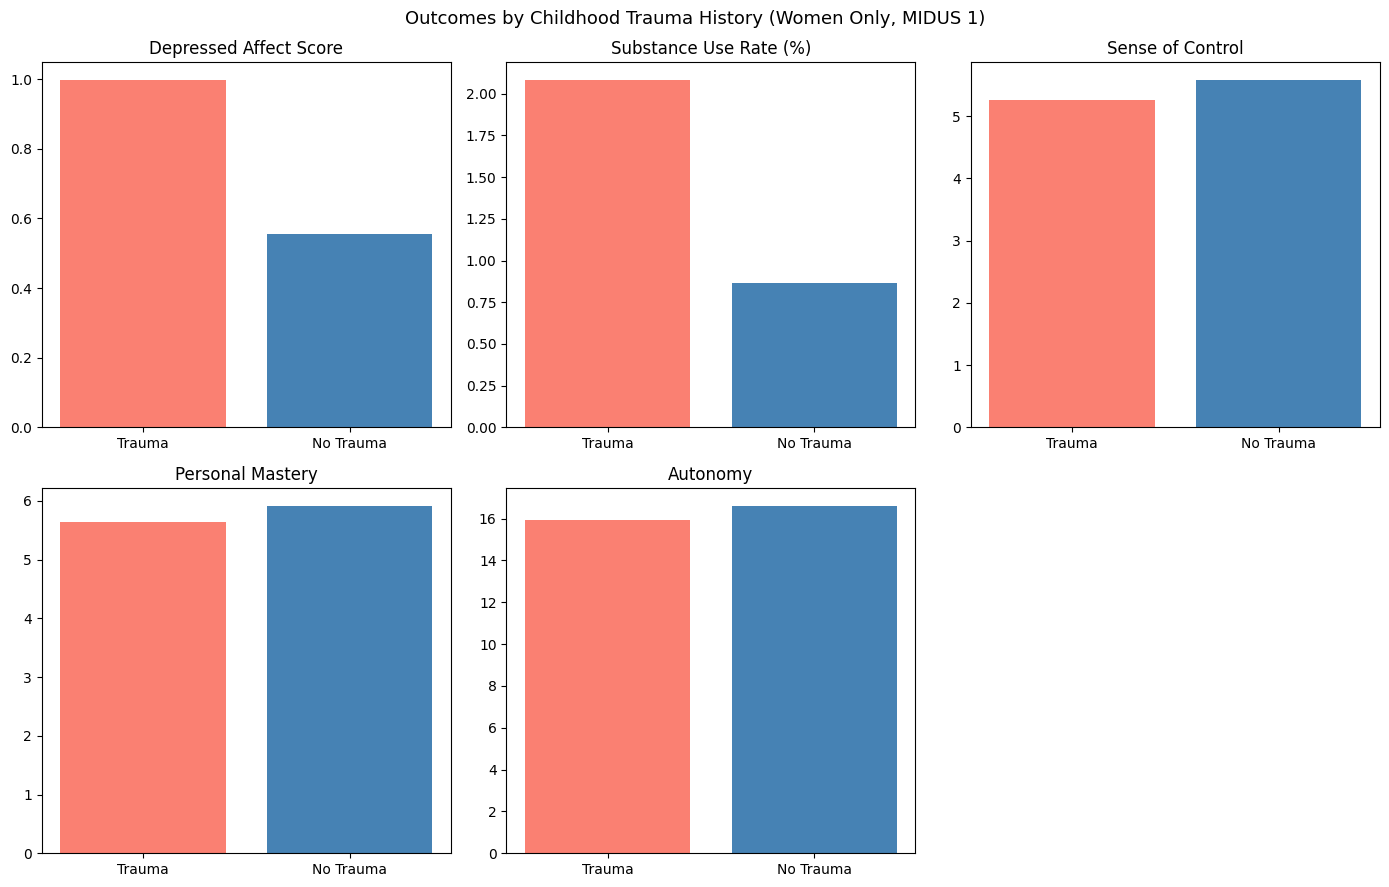

In [64]:
##### 11. VISUALISE GROUP DIFFERENCES: BAR CHART

fig, axes = plt.subplots(2, 3, figsize=(14, 9)) # subplots(2,3) creates 6 panels but we only have 5 variables
fig.suptitle("Outcomes by Childhood Trauma History (Women Only, MIDUS 1)", fontsize=13)

plot_vars = [ #true and false is used if the variable should be convrted to % or not
    ("dep_score",     "Depressed Affect Score", False),
    ("substance_use", "Substance Use Rate (%)", True),
    ("sense_control", "Sense of Control",       False),
    ("mastery",       "Personal Mastery",       False),
    ("autonomy",      "Autonomy",               False),
]

for ax, (var, title, is_pct) in zip(axes.ravel(), plot_vars): #ravel to flatten the plot

  t_mean = trauma[var].mean() #using the trauma group means
  nt_mean = no_trauma[var].mean()
  if is_pct:
    t_mean *= 100
    nt_mean *= 100

  ax.bar(["Trauma", "No Trauma"], [t_mean, nt_mean], color=["salmon", "steelblue"])
  ax.set_title(title)
fig.delaxes(axes[1, 2]) #i kept getting a 6th empty plot because I used 2x3 so I added this code to remove the last one.

plt.tight_layout()
plt.show()

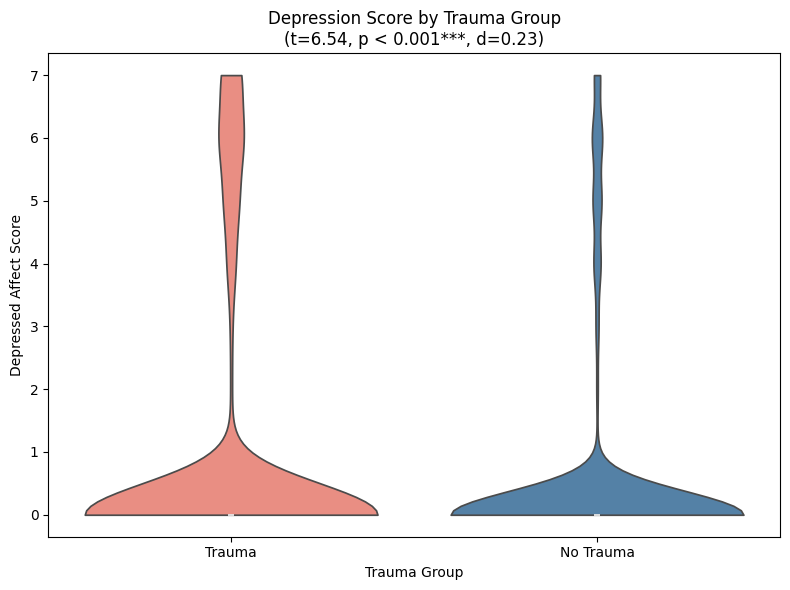

In [65]:
##### 12. VISUALISE GROUP DIFFERENCES:VIOLIN PLOT
# violin plot can show averages, spread of scores and density/distribution shape better
dep_row = results_df[results_df["Variable"] == "Depression Score"].iloc[0]
t_dep   = dep_row["t"]
d_dep   = dep_row["Cohen's d"]
# pulling t and Cohen's d directly from the results table
# so this cell works even if run on its own without re-running the loop above
plt.figure(figsize=(8, 6))
sns.violinplot(
    data=df.dropna(subset=["trauma_group","dep_score"]),
    x="trauma_group",
    y="dep_score",
    hue="trauma_group",
    palette={"Trauma":"salmon","No Trauma":"steelblue"},
    legend=False,
    cut = 0 #Prevents Violins from extending Bbyond Data
)
plt.title(f"Depression Score by Trauma Group\n(t={round(t_dep,2)}, p < 0.001***, d={round(d_dep,2)})")
plt.xlabel("Trauma Group")
plt.ylabel("Depressed Affect Score")
plt.tight_layout()
plt.show()

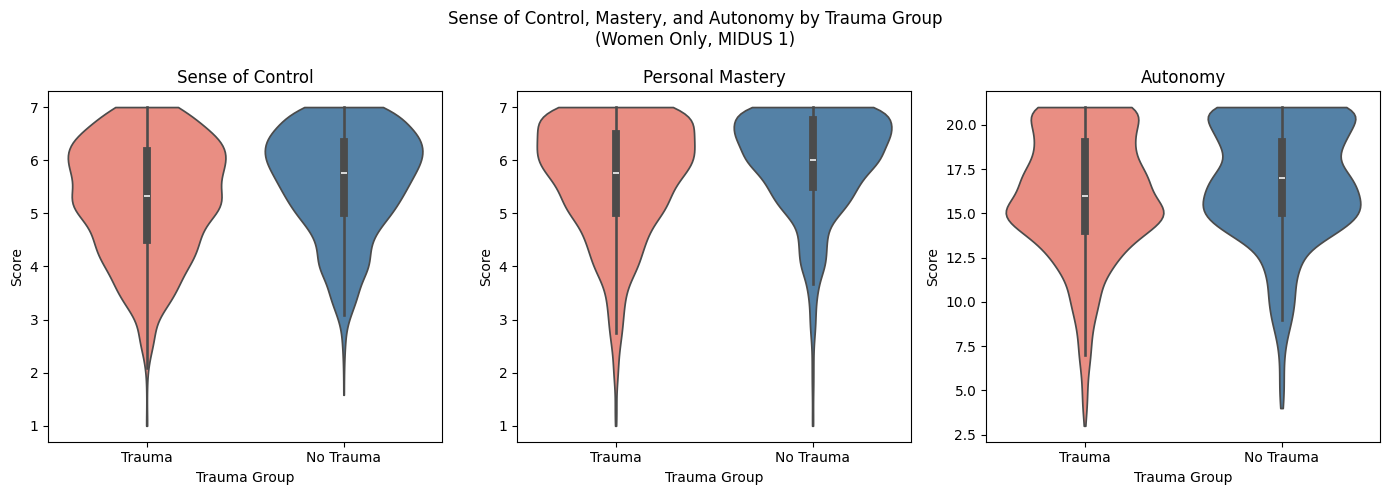

In [66]:
##### 13. VIOLIN PLOTS: CONTROL AND AUTONOMY BY TRAUMA GROUP
#violin plot to see group differences, score distributions and variability within each group for women with and w/out trauma
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Sense of Control, Mastery, and Autonomy by Trauma Group\n(Women Only, MIDUS 1)", fontsize=12)

for ax, (var, label) in zip(axes, [ #Match Axes to Variables
    ("sense_control", "Sense of Control"),
    ("mastery",       "Personal Mastery"),
    ("autonomy",      "Autonomy"),
]):
    sns.violinplot(
        data=df.dropna(subset=["trauma_group", var]),
        x="trauma_group",
        y=var,
        hue="trauma_group",
        palette={"Trauma":"salmon","No Trauma":"steelblue"},
        legend=False,
        cut=0,
        ax=ax # draws the plot on specific subplot
    )
    ax.set_title(label)
    ax.set_xlabel("Trauma Group")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

In [67]:
##### 14. CORRELATION ANALYSIS
# Does higher abuse relate to higher depression?
# Does higher abuse relate to lower autonomy/control/mastery?
# Does income or education relate to depression?

# using Spearman r creating a dataset first
corr_df = df[["abuse_score","dep_score","depression","substance_use",
              "sense_control","mastery","autonomy",
              "log_income","education","age"]].dropna()

print(f"\nComplete cases for correlation: {len(corr_df)}")
print()

pairs = [ #starting a loop
    ("abuse_score", "depression",    "Abuse vs Depression"),
    ("abuse_score", "substance_use", "Abuse vs Substance use"),
    ("abuse_score", "sense_control", "Abuse vs Sense of control"),
    ("abuse_score", "mastery",       "Abuse vs Personal mastery"),
    ("abuse_score", "autonomy",      "Abuse vs Autonomy"),
    ("log_income",  "depression",    "Income vs Depression"),
    ("education",   "depression",    "Education vs Depression"),
]

for x, y, label in pairs:
    r, p = spearmanr(corr_df[x], corr_df[y])
    p_str = "p < 0.001" if p < 0.001 else f"p = {round(p,4)}"
    print(f"{label}: r = {round(r,2)}, {p_str}")


Complete cases for correlation: 3046

Abuse vs Depression: r = -0.15, p < 0.001
Abuse vs Substance use: r = -0.07, p < 0.001
Abuse vs Sense of control: r = 0.18, p < 0.001
Abuse vs Personal mastery: r = 0.15, p < 0.001
Abuse vs Autonomy: r = 0.12, p < 0.001
Income vs Depression: r = -0.06, p < 0.001
Education vs Depression: r = -0.06, p = 0.0023


In [68]:
# ensure substance_use is float for statsmodels logistic regression
df["substance_use"] = df["substance_use"].astype(float) #doesnt run without this

In [69]:
##### 15. REGRESSION MODELS
#Does childhood abuse predict depression, substance use, control, mastery, and autonomy, even after controlling for age, income, and education
# logistic regression for binary outcomes (depression, substance use)
# OLS (ordinary least squares) for continuous outcomes (control, mastery, autonomy)

outcomes = [ #Define Outcomes
    ("depression", "Depression"),
    ("substance_use", "Substance Use"),
    ("sense_control", "Sense of Control"),
    ("mastery", "Personal Mastery"),
    ("autonomy", "Autonomy"),
]
reg_df = df.dropna(subset=[ #creating dataset
    "depression","substance_use","sense_control","mastery",
    "autonomy","abuse_score","log_income","education","age"
]).copy()
binary_outcomes = ["depression", "substance_use"] #defining binary for LR
print(f"\nComplete cases for regression: {len(reg_df)}")
all_results = {}

for outcome, label in outcomes:

    print(f"\n{'='*50}\n{label}\n{'='*50}")

    is_logit = outcome in binary_outcomes #Determine regression type

    # Models
    m1 = smf.logit(f"{outcome} ~ abuse_score", reg_df).fit(disp=0) if is_logit else \
         smf.ols(f"{outcome} ~ abuse_score", reg_df).fit()

    m2 = smf.logit(
        f"{outcome} ~ abuse_score + log_income + education + age",
        reg_df
    ).fit(disp=0) if is_logit else smf.ols(
        f"{outcome} ~ abuse_score + log_income + education + age",
        reg_df
    ).fit()

    #Model 1 - Does abuse score alone predict the outcome
    p1 = m1.pvalues["abuse_score"]
    effect1 = np.exp(m1.params["abuse_score"]) if is_logit else m1.params["abuse_score"]

    print(
        f"\nModel 1: {'OR' if is_logit else 'β'} = {round(effect1,3)}, "
        f"p = {'< 0.001' if p1 < 0.001 else round(p1,4)}, "
        f"{sig_label(p1)}"
    )

    #Model 2 table controlling for income, education and age.
    rows = []

    for pred in m2.params.index:#Loop Through Predictors

        p = m2.pvalues[pred]
        effect = np.exp(m2.params[pred]) if is_logit else m2.params[pred]

        rows.append({
            "predictor": pred,
            "effect": round(effect, 3),
            "SE": round(m2.bse[pred], 3),
            "p": "< 0.001" if p < 0.001 else round(p, 4),
            "sig": sig_label(p)
        })

    result_df = pd.DataFrame(rows)

    print("\nModel 2 (adjusted):")
    display(result_df)

    all_results[outcome] = result_df


Complete cases for regression: 3046

Depression

Model 1: OR = 0.524, p = < 0.001, p<0.001***

Model 2 (adjusted):


,predictor,effect,SE,p,sig
0,Intercept,36.777,0.623,< 0.001,p<0.001***
1,abuse_score,0.544,0.075,< 0.001,p<0.001***
2,log_income,0.832,0.053,< 0.001,p<0.001***
3,education,0.945,0.024,0.0196,p<0.05*
4,age,0.971,0.004,< 0.001,p<0.001***



Substance Use

Model 1: OR = 0.447, p = < 0.001, p<0.001***

Model 2 (adjusted):


,predictor,effect,SE,p,sig
0,Intercept,41.554,1.455,0.0104,p<0.05*
1,abuse_score,0.473,0.211,< 0.001,p<0.001***
2,log_income,0.640,0.126,< 0.001,p<0.001***
3,education,1.034,0.070,0.6346,ns
4,age,0.969,0.012,0.0101,p<0.05*



Sense of Control

Model 1: β = 0.286, p = < 0.001, p<0.001***

Model 2 (adjusted):


,predictor,effect,SE,p,sig
0,Intercept,3.245,0.226,< 0.001,p<0.001***
1,abuse_score,0.279,0.027,< 0.001,p<0.001***
2,log_income,0.128,0.019,< 0.001,p<0.001***
3,education,0.057,0.008,< 0.001,p<0.001***
4,age,-0.008,0.001,< 0.001,p<0.001***



Personal Mastery

Model 1: β = 0.233, p = < 0.001, p<0.001***

Model 2 (adjusted):


,predictor,effect,SE,p,sig
0,Intercept,4.701,0.232,< 0.001,p<0.001***
1,abuse_score,0.233,0.028,< 0.001,p<0.001***
2,log_income,0.050,0.020,0.0111,p<0.05*
3,education,0.014,0.008,0.086,ns
4,age,-0.005,0.001,0.0015,p<0.01**



Autonomy

Model 1: β = 0.576, p = < 0.001, p<0.001***

Model 2 (adjusted):


,predictor,effect,SE,p,sig
0,Intercept,12.199,0.770,< 0.001,p<0.001***
1,abuse_score,0.523,0.092,< 0.001,p<0.001***
2,log_income,0.039,0.065,0.5436,ns
3,education,0.069,0.028,0.0127,p<0.05*
4,age,0.035,0.005,< 0.001,p<0.001***


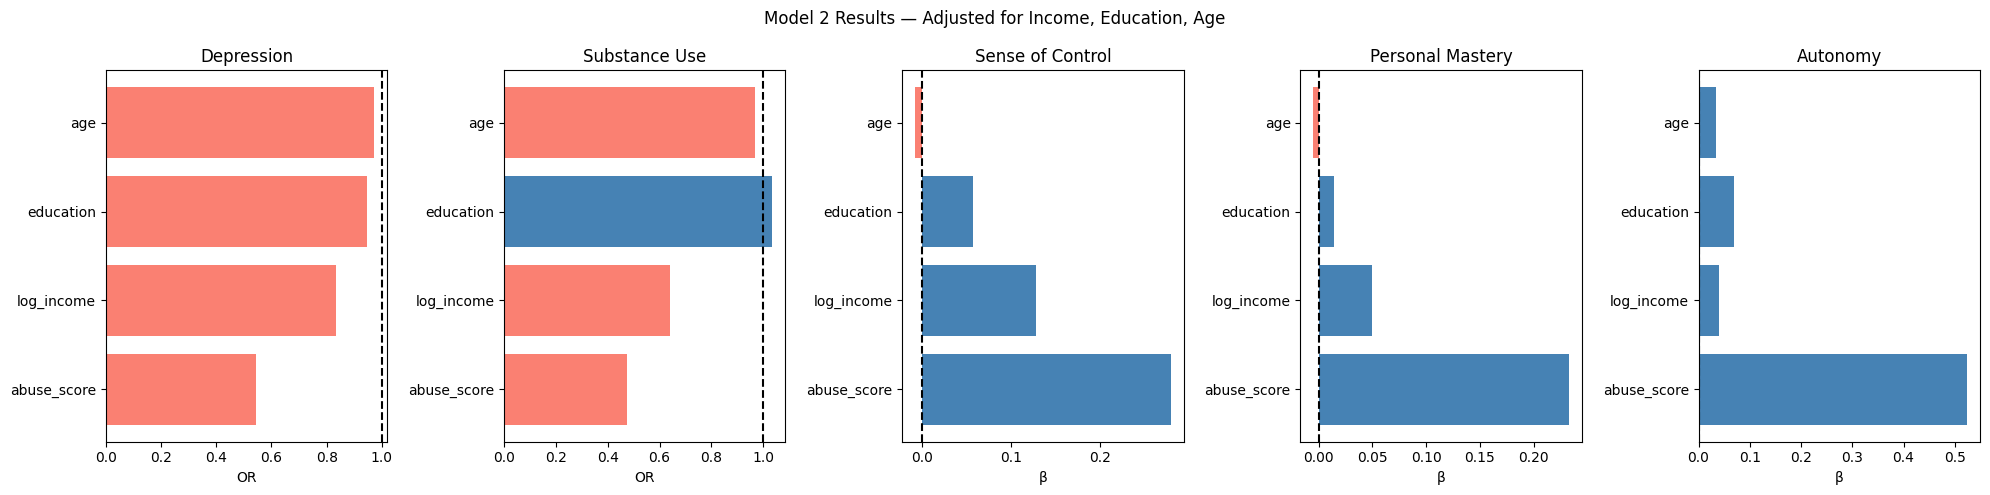

In [70]:
##### 16. ODDS RATIO PLOT - visualizing model 2

# for logistic regression the reference line is 1 (OR=1 means no effect)
# for OLS the reference line is 0 (beta=0 means no effect)
# salmon = worse outcome for trauma group, steelblue = better
fig, axes = plt.subplots(1, 5, figsize=(20, 5))
fig.suptitle(
    "Model 2 Results — Adjusted for Income, Education, Age",
    fontsize=12
)

for ax, (outcome, label) in zip(axes, outcomes): #Loop Through Outcomes and Axes

    if outcome not in all_results: #checking whether results exist
        ax.set_title(f"{label}\n(no model)")
        ax.axis("off")
        continue

    df_plot = all_results[outcome]
    df_plot = df_plot[df_plot["predictor"] != "Intercept"] # Removing intercept so graph is not cluttered

    is_logit = outcome in binary_outcomes #determines R type like previous section
    col = "effect" #effect column

    ref = 1 if is_logit else 0 #reference line

    colors = [
        "salmon" if (v < ref if is_logit else v < 0) else "steelblue"
        for v in df_plot[col] #tried to use colors in the loop itself
    ]

    ax.barh(df_plot["predictor"], df_plot[col], color=colors) #bars are horizontal
    ax.axvline(ref, color="black", linestyle="--") #adds the reference line that i created earlier

    ax.set_title(label)
    ax.set_xlabel("OR" if is_logit else "β")

plt.tight_layout()
plt.show()